# Vanishing Gradient Problem

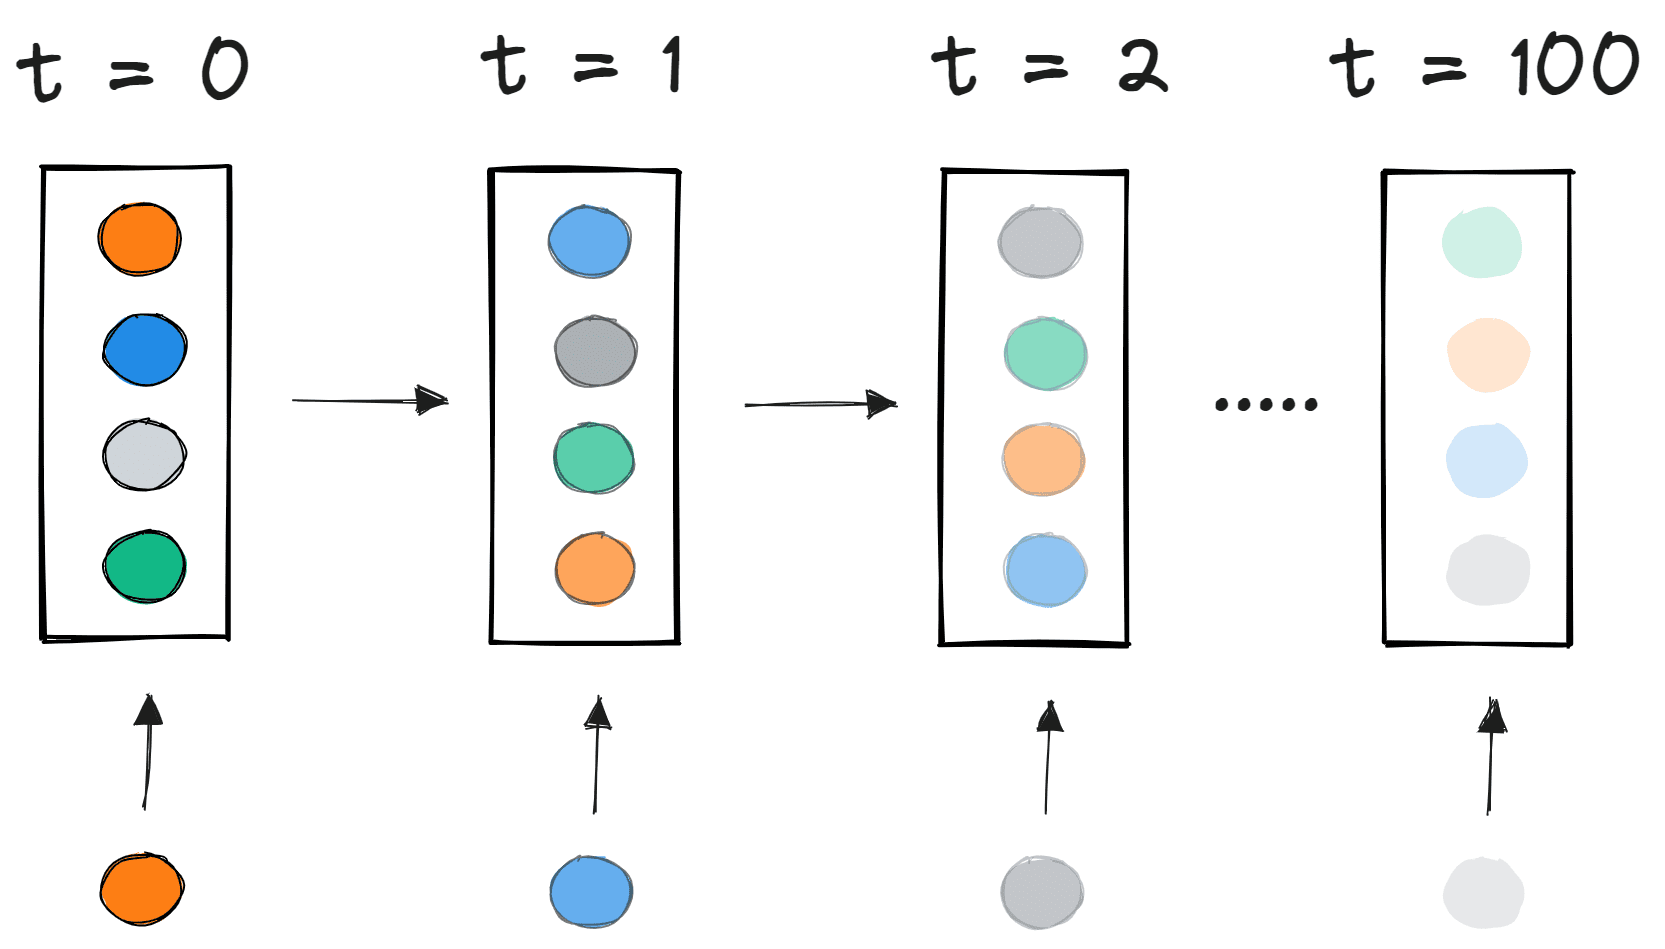

https://medium.com/@El_Fares_Anass/a-basic-explanation-how-the-gradient-descent-is-determined-during-back-propagation-864376f8f1a4

https://www.kdnuggets.com/2022/02/vanishing-gradient-problem.html

https://kharshit.github.io/blog/2019/01/04/the-gradient-problem-in-rnn



2026-04-25 18:00:55.602023: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-25 18:00:56.152639: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-25 18:00:57.660892: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-25 18:00:59.025350: E external/local_xla/xla/stream_ex

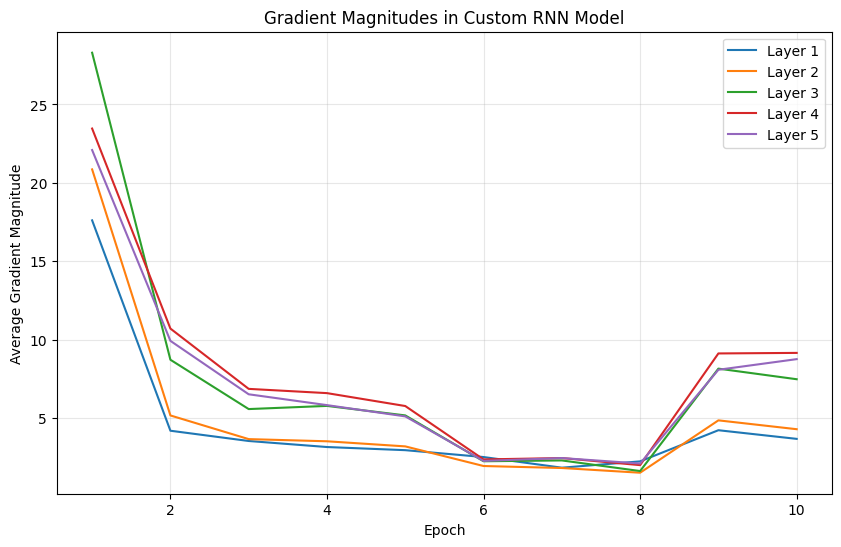

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
#np.random.seed(42)
#tf.random.set_seed(42)

# Generate some toy data
X = np.random.rand(1000, 10, 1)
y = np.random.randint(0, 2, size=(1000, 1))

# Define a custom RNN model (виправлений)
class CustomRNNModel(tf.keras.Model):
    def __init__(self, units, depth):
        super(CustomRNNModel, self).__init__()
        self.depth = depth
        self.rnn_layer = [tf.keras.layers.SimpleRNN(units, return_sequences=True) 
                         for _ in range(depth)]
        self.dense_layer = tf.keras.layers.Dense(1, activation='sigmoid')

    def call(self, inputs):
        states = inputs
        for i in range(self.depth):
            states = self.rnn_layer[i](states)
        outputs = self.dense_layer(states[:, -1, :])
        return outputs

# Create the custom RNN model
units = 10
depth = 5
model_rnn = CustomRNNModel(units, depth)

# Compile the model
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define a function to compute gradients
def get_gradients(inputs, labels, model):
    with tf.GradientTape(persistent=True) as tape:
        predictions = model(inputs, training=True)
        loss = tf.keras.losses.binary_crossentropy(labels, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    del tape
    return gradients

# Train the model and track gradients
num_epochs = 10
gradients_history = [[] for _ in range(depth)]

for epoch in range(num_epochs):
    model_rnn.fit(X, y, batch_size=32, epochs=1, verbose=0)
    gradients = get_gradients(X, y, model_rnn)
    
    # Збираємо градієнти для кожного RNN шару
    for i in range(depth):
        # Кожен RNN шар має 2 trainable variables (kernel, recurrent_kernel, bias)
        # Або перевірте точну структуру
        layer_grads = [g for j, g in enumerate(gradients) 
                      if j // 3 == i and g is not None]  # приблизне групування
        if layer_grads:
            avg_gradient_magnitude = np.mean([tf.norm(g).numpy() for g in layer_grads])
            gradients_history[i].append(avg_gradient_magnitude)

# Plot the gradient magnitudes
plt.figure(figsize=(10, 6))
for i in range(depth):
    plt.plot(range(1, num_epochs + 1), gradients_history[i], label=f'Layer {i+1}')
plt.xlabel('Epoch')
plt.ylabel('Average Gradient Magnitude')
plt.title('Gradient Magnitudes in Custom RNN Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# GRU

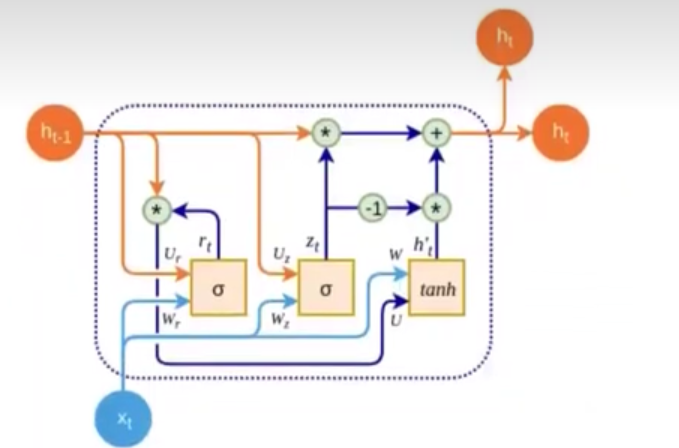


https://medium.com/@anishnama20/understanding-gated-recurrent-unit-gru-in-deep-learning-2e54923f3e2

https://d2l.ai/chapter_recurrent-modern/gru.html

https://github.com/kaustubhhivare/LSTM-GRU-from-scratch/blob/master/module.py


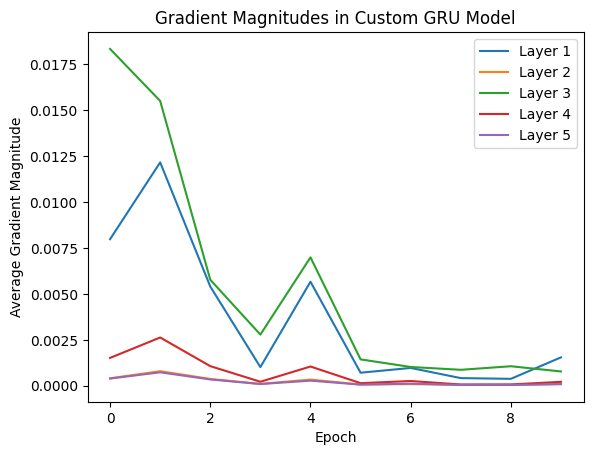

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Define a custom GRU model 
class CustomGRUModel(tf.keras.Model):
    def __init__(self, units, depth):
        super(CustomGRUModel, self).__init__()
        self.depth = depth
        self.gru_layers = [tf.keras.layers.GRU(units, return_sequences=True) 
                         for _ in range(depth)]
        self.dense = tf.keras.layers.Dense(1, activation='sigmoid')

    def call(self, inputs):
        states = inputs
        for i in range(self.depth):
            states = self.gru_layers[i](states)
        outputs = self.dense(states[:, -1, :]) # Take only the last output of the last layer
        return outputs
    
# Create the custom GRU model
units = 10
depth = 5
model_gru = CustomGRUModel(units, depth)

# Compile the model
model_gru.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


# Define a function to compute gradients - average gradient magnitude for each layer
def get_gradients(inputs, model):
    with tf.GradientTape(persistent=True) as tape:
        predictions = model(inputs)
        loss = tf.keras.losses.binary_crossentropy(y, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    del tape
    return gradients

# Train the model and track gradients
num_epochs = 10
gradients_history = [[] for _ in range(depth)]
for epoch in range(num_epochs):
    model_gru.fit(X, y, batch_size=32, epochs=1, verbose=0)
    gradients = get_gradients(X, model_gru)
    
    # Збираємо градієнти для кожного GRU шару
    for i in range(depth):
        if gradients[i] is not None:            
            gradients_history[i].append(np.mean([np.mean(np.abs(grad)) for grad in gradients[i]]))

        model_gru.fit(X, y, batch_size=32, epochs=1, verbose=0)

# Plot the gradient magnitudes
for i in range(depth):
    plt.plot(gradients_history[i], label=f'Layer {i+1}')
plt.xlabel('Epoch')
plt.ylabel('Average Gradient Magnitude')
plt.title('Gradient Magnitudes in Custom GRU Model')
plt.legend()
plt.show()

# LSTM

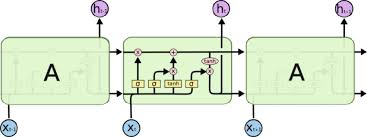

https://d2l.ai/chapter_recurrent-modern/lstm.html


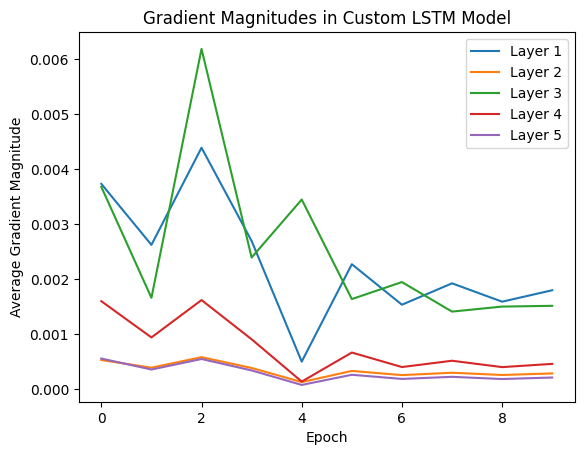

In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Define a custom LSTM model
class CustomLSTMModel(tf.keras.Model):
    def __init__(self, units, depth):
        super(CustomLSTMModel, self).__init__()
        self.depth = depth
        self.lstm_layers = [tf.keras.layers.LSTM(units, return_sequences=True) 
                         for _ in range(depth)]
        self.dense = tf.keras.layers.Dense(1, activation='sigmoid')

    def call(self, inputs):
        states = inputs
        for i in range(self.depth):
            states = self.lstm_layers[i](states)
        outputs = self.dense(states[:, -1, :]) # Take only the last output of the last layer
        return outputs
    
# Create the custom LSTM model
units = 10
depth = 5
model_lstm = CustomLSTMModel(units, depth)

# Compile the model
model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define a function to compute gradients - average gradient magnitude for each layer
def get_gradients(inputs, model):
    with tf.GradientTape(persistent=True) as tape:
        predictions = model(inputs)
        loss = tf.keras.losses.binary_crossentropy(y, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    del tape
    return gradients

# Train the model and track gradients
num_epochs = 10
gradients_history = [[] for _ in range(depth)]
for epoch in range(num_epochs):
    model_lstm.fit(X, y, batch_size=32, epochs=1, verbose=0)
    gradients = get_gradients(X, model_lstm)
    
    # Збираємо градієнти для кожного LSTM шару
    for i in range(depth):
        if gradients[i] is not None:            
            gradients_history[i].append(np.mean([np.mean(np.abs(grad)) for grad in gradients[i]]))
    model_lstm.fit(X, y, batch_size=32, epochs=1, verbose=0)

# Plot the gradient magnitudes
for i in range(depth):
    plt.plot(gradients_history[i], label=f'Layer {i+1}')
plt.xlabel('Epoch')
plt.ylabel('Average Gradient Magnitude')
plt.title('Gradient Magnitudes in Custom LSTM Model')
plt.legend()
plt.show()

# Comparison

In [7]:
import numpy as np
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from keras.optimizers import Adam

# Generate some toy data
X = np.random.randn(1000, 1000, 100) # 1000 sequences of length 1000 with 100 features
y = np.random.randint(0, 2, size=(1000, )) # Binary labels for each sequence

# Define a simple RNN model
model = Sequential()
model.add(SimpleRNN(10, input_shape=(1000, 100), return_sequences=False))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])

# Train the model and track gradients
history_rnn = model.fit(X, y, epochs=10, batch_size=32)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.5110 - loss: 0.7502
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.6720 - loss: 0.6321
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.7100 - loss: 0.5812
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.7410 - loss: 0.5304
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.7870 - loss: 0.4656
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.8150 - loss: 0.4173
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.8480 - loss: 0.3751
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.8830 - loss: 0.3270
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.8960 - loss: 0.2841
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.8870 - loss: 0.3020


In [6]:
from keras.layers import LSTM

# Define a simple LSTM model
model = Sequential()
model.add(LSTM(10, input_shape=(1000, 100), return_sequences=False))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])

# Train the model and track gradients
history_lstm = model.fit(X, y, epochs=10, batch_size=32)

Epoch 1/10


/home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/.ds_lect_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.5200 - loss: 0.7021
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.7550 - loss: 0.5955
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - accuracy: 0.8380 - loss: 0.4603
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.9400 - loss: 0.2786
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.9850 - loss: 0.1443
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.9950 - loss: 0.0766
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 1.0000 - loss: 0.0405
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 1.0000 - loss: 0.0237
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 1.0000 - loss: 0.0150
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 1.0000 - loss: 0.0107


/tmp/ipykernel_12325/2029396362.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(epochs, acc_lstm, 'r-', label='LSTM Accuracy', c='red') # Графік точності LSTM на тренувальних даних
/tmp/ipykernel_12325/2029396362.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(epochs, loss_lstm, 'r-', label='LSTM Loss', c='red') # Графік втрат LSTM на тренувальних даних


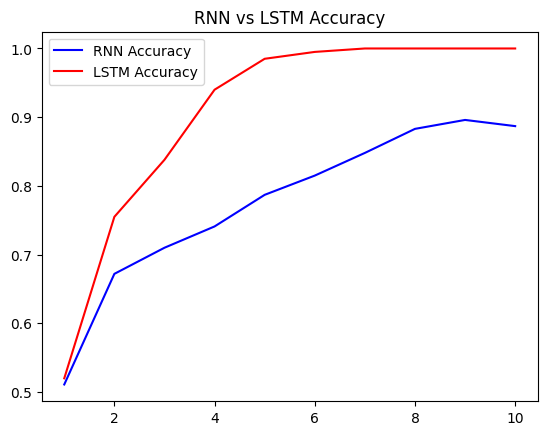

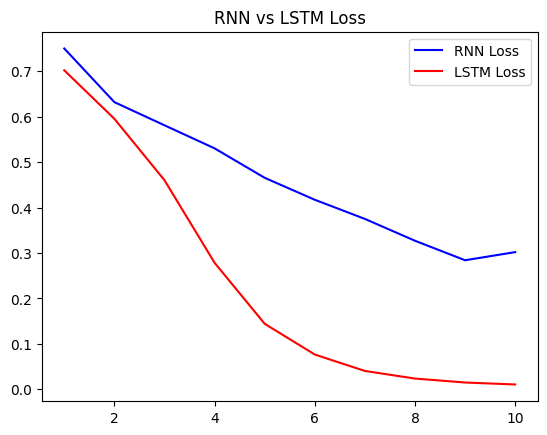

In [8]:
acc_rnn = history_rnn.history['accuracy']
loss_rnn = history_rnn.history['loss']

acc_lstm = history_lstm.history['accuracy']
loss_lstm = history_lstm.history['loss']

epochs = range(1, len(acc_rnn) + 1)

plt.plot(epochs, acc_rnn, 'b-', label='RNN Accuracy') # Графік точності RNN на тренувальних даних
plt.plot(epochs, acc_lstm, 'r-', label='LSTM Accuracy', c='red') # Графік точності LSTM на тренувальних даних
plt.title('RNN vs LSTM Accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss_rnn, 'b-', label='RNN Loss') # Графік втрат RNN на тренувальних даних
plt.plot(epochs, loss_lstm, 'r-', label='LSTM Loss', c='red') # Графік втрат LSTM на тренувальних даних
plt.title('RNN vs LSTM Loss')
plt.legend()

plt.show()

In [9]:
# Introduce long-range dependencies

# Generate sythetic data with long-range dependencies
#X = np.random.rand(1000, 1000, 100)
#y = np.random.randint(0, 2, size=(1000, )) # Binary labels for each sequence

# Define long-range dependencies
for i in range(len(X)):
    if np.random.rand() < 0.2: # Introduce a long-range dependency in 20% of the sequences
        X[i, 580:, 0] += 5.0 # Add a large value to the second half of the sequence
        y[i] = 1 # Set the label to 1 if the first feature is 1

# Define and train the RNN model
model = Sequential()
model.add(SimpleRNN(10, input_shape=(1000, 100), return_sequences=False))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])
history_rnn = model.fit(X, y, epochs=10, batch_size=32)



Epoch 1/10


/home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/.ds_lect_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.5700 - loss: 0.7303
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.7290 - loss: 0.5307
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.7820 - loss: 0.4718
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.8210 - loss: 0.4182
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.8400 - loss: 0.3740
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.8600 - loss: 0.3314
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.9000 - loss: 0.2749
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.9050 - loss: 0.2398
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.9350 - loss: 0.2117
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.9360 - loss: 0.1855


In [10]:
# Define and train the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(10, input_shape=(1000, 100), return_sequences=False))
model_lstm.add(Dense(1, activation='sigmoid'))
model_lstm.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])
history_lstm = model_lstm.fit(X, y, epochs=10, batch_size=32)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.5890 - loss: 0.6134
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.8180 - loss: 0.4483
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.8960 - loss: 0.3162
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.9710 - loss: 0.1739
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.9960 - loss: 0.0847
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.9990 - loss: 0.0421
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 1.0000 - loss: 0.0227
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 1.0000 - loss: 0.0144
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 1.0000 - loss: 0.0095
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 1.0000 - loss: 0.0069


/tmp/ipykernel_12325/3409827072.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(epochs, acc_lstm, 'r-', label='LSTM Accuracy', c='red') # Графік точності LSTM на тренувальних даних
/tmp/ipykernel_12325/3409827072.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(epochs, loss_lstm, 'r-', label='LSTM Loss', c='red') # Графік втрат LSTM на тренувальних даних


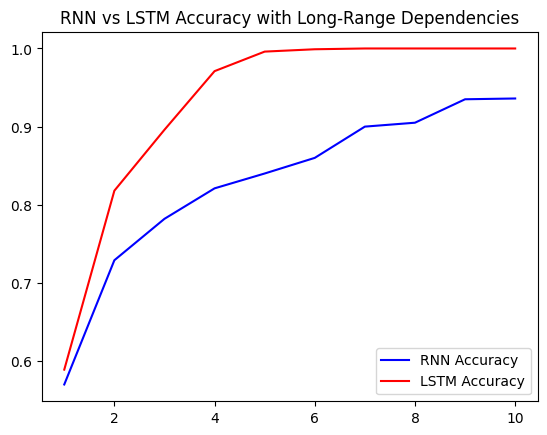

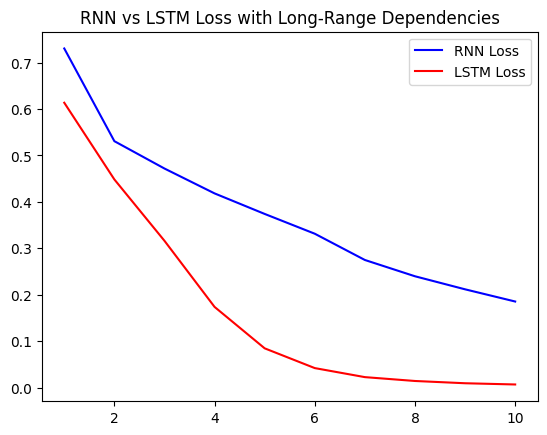

In [11]:
acc_rnn = history_rnn.history['accuracy']
loss_rnn = history_rnn.history['loss']

acc_lstm = history_lstm.history['accuracy']
loss_lstm = history_lstm.history['loss']

epochs = range(1, len(acc_rnn) + 1)

plt.plot(epochs, acc_rnn, 'b-', label='RNN Accuracy') # Графік точності RNN на тренувальних даних
plt.plot(epochs, acc_lstm, 'r-', label='LSTM Accuracy', c='red') # Графік точності LSTM на тренувальних даних
plt.title('RNN vs LSTM Accuracy with Long-Range Dependencies')
plt.legend()

plt.figure()

plt.plot(epochs, loss_rnn, 'b-', label='RNN Loss') # Графік втрат RNN на тренувальних даних
plt.plot(epochs, loss_lstm, 'r-', label='LSTM Loss', c='red') # Графік втрат LSTM на тренувальних даних
plt.title('RNN vs LSTM Loss with Long-Range Dependencies')
plt.legend()    

plt.show()